In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
master_data = pd.read_csv("/content/master_influenza_dataset.csv", parse_dates=["Date"])
master_data.head()

,Year,Week,ILI_Total,Total_Patients,Weighted_ILI,Region,Season,Date,Population_2024,ILI_per_100k
0,2019,40,5637,333469,1.67601,Region 4,2019_20,2019-09-30,70994814.0,7.940017
1,2019,41,5349,317260,1.63170,Region 4,2019_20,2019-10-07,70994814.0,7.534353
2,2019,42,5711,311644,1.81532,Region 4,2019_20,2019-10-14,70994814.0,8.044250
3,2019,43,6683,322052,1.96609,Region 4,2019_20,2019-10-21,70994814.0,9.413364
4,2019,44,7119,318970,2.29988,Region 4,2019_20,2019-10-28,70994814.0,10.027493


In [ ]:
print("Shape:", master_data.shape)
master_data.info()

Shape: (780, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Year             780 non-null    int64         
 1   Week             780 non-null    int64         
 2   ILI_Total        780 non-null    int64         
 3   Total_Patients   780 non-null    int64         
 4   Weighted_ILI     780 non-null    float64       
 5   Region           780 non-null    object        
 6   Season           780 non-null    object        
 7   Date             780 non-null    datetime64[ns]
 8   Population_2024  780 non-null    float64       
 9   ILI_per_100k     780 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(4), object(2)
memory usage: 61.1+ KB


In [ ]:
print("Regions:", master_data["Region"].unique())
print("Seasons:", master_data["Season"].unique())

Regions: ['Region 4' 'Region 6' 'Region 9']
Seasons: ['2019_20' '2021_22' '2022_23' '2023_24' '2024_25']


In [ ]:
master_data = master_data.sort_values(by=["Region", "Date"]).reset_index(drop=True)
master_data.head()

,Year,Week,ILI_Total,Total_Patients,Weighted_ILI,Region,Season,Date,Population_2024,ILI_per_100k
0,2019,40,5637,333469,1.67601,Region 4,2019_20,2019-09-30,70994814.0,7.940017
1,2019,41,5349,317260,1.63170,Region 4,2019_20,2019-10-07,70994814.0,7.534353
2,2019,42,5711,311644,1.81532,Region 4,2019_20,2019-10-14,70994814.0,8.044250
3,2019,43,6683,322052,1.96609,Region 4,2019_20,2019-10-21,70994814.0,9.413364
4,2019,44,7119,318970,2.29988,Region 4,2019_20,2019-10-28,70994814.0,10.027493


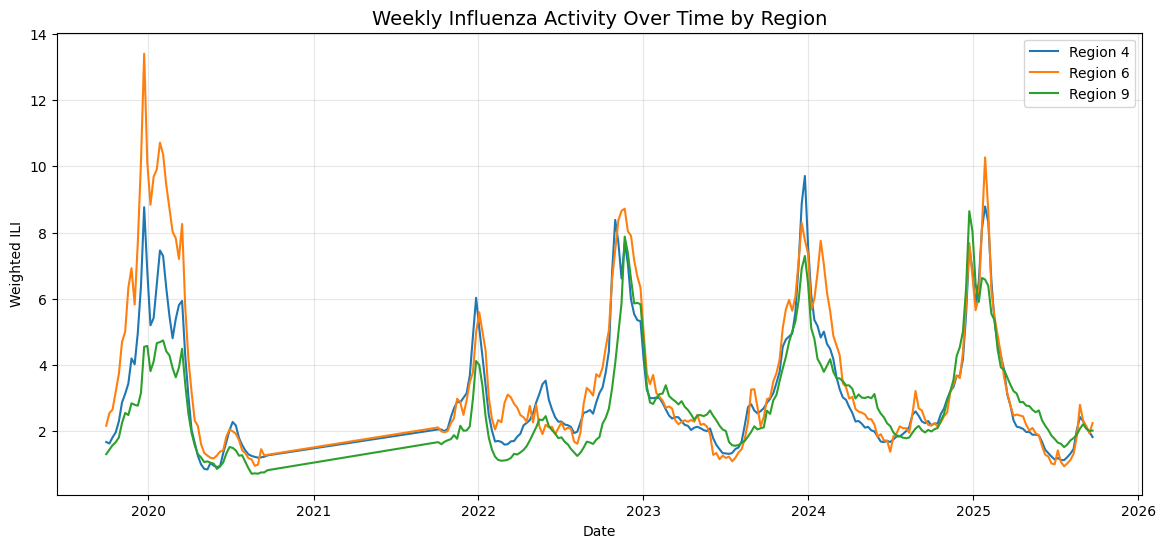

In [ ]:
plt.figure(figsize=(14, 6))

for region in master_data["Region"].unique():
    subset = master_data[master_data["Region"] == region]
    plt.plot(subset["Date"], subset["Weighted_ILI"], label=region)

plt.title("Weekly Influenza Activity Over Time by Region", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Weighted ILI")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

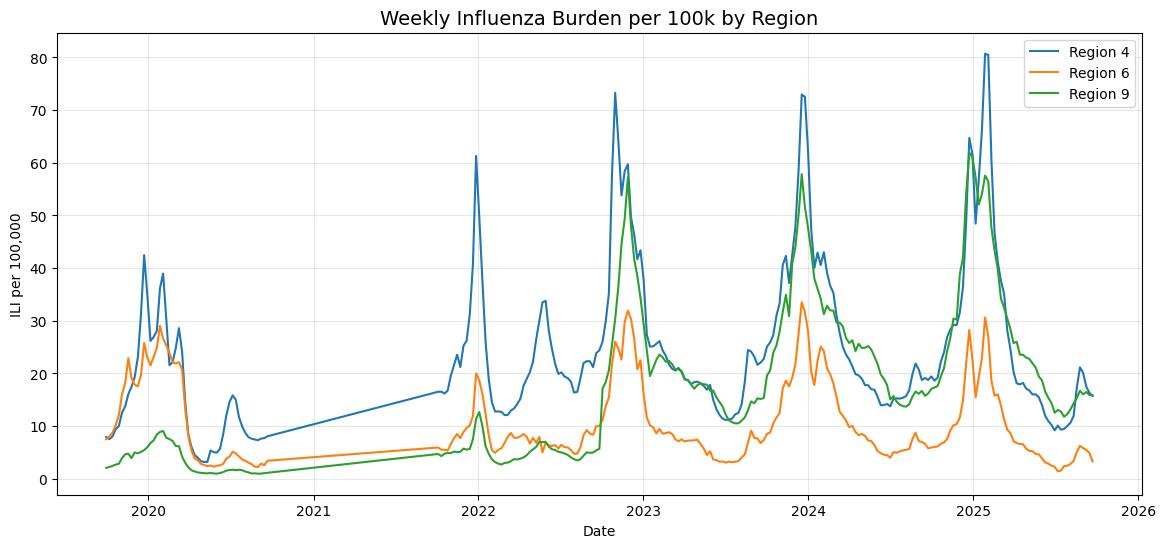

In [ ]:
plt.figure(figsize=(14, 6))

for region in master_data["Region"].unique():
    subset = master_data[master_data["Region"] == region]
    plt.plot(subset["Date"], subset["ILI_per_100k"], label=region)

plt.title("Weekly Influenza Burden per 100k by Region", fontsize=14)
plt.xlabel("Date")
plt.ylabel("ILI per 100,000")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

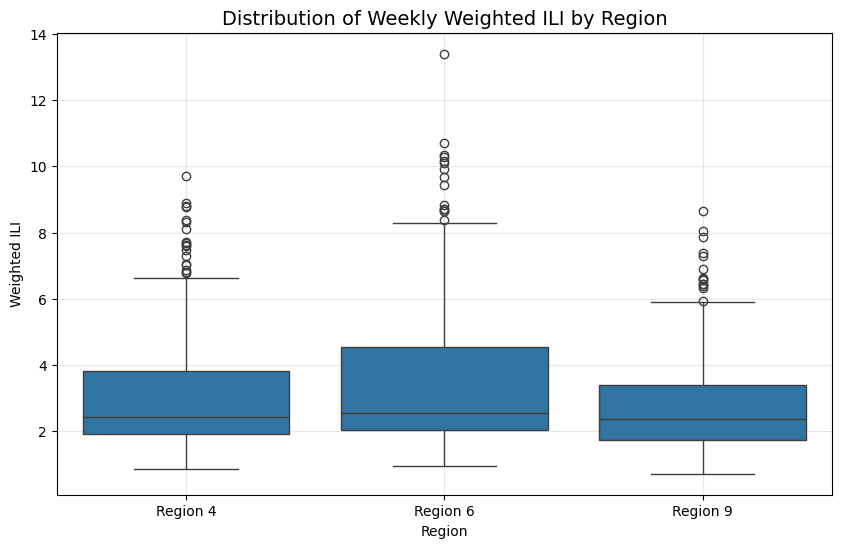

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_data, x="Region", y="Weighted_ILI")
plt.title("Distribution of Weekly Weighted ILI by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Weighted ILI")
plt.grid(True, alpha=0.3)
plt.show()

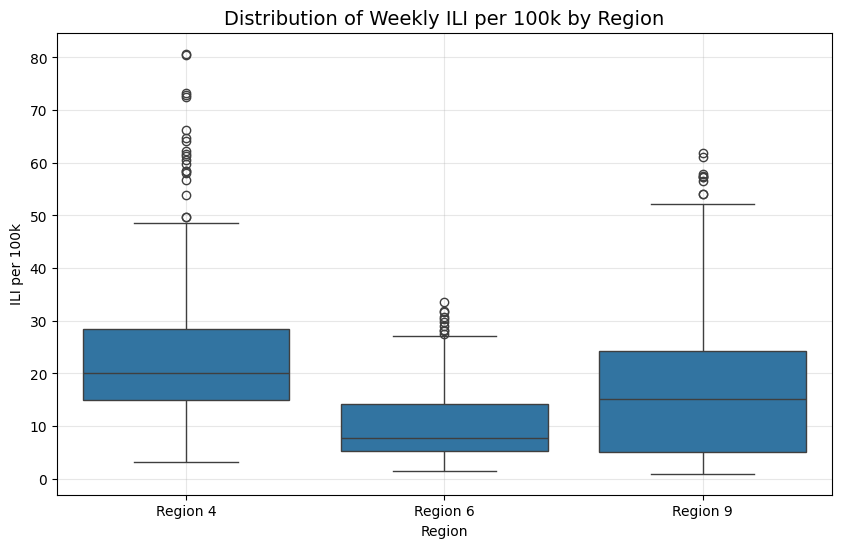

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_data, x="Region", y="ILI_per_100k")
plt.title("Distribution of Weekly ILI per 100k by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("ILI per 100k")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
master_data["Weighted_ILI_MA3"] = master_data.groupby("Region")["Weighted_ILI"].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

master_data.head()

,Year,Week,ILI_Total,Total_Patients,Weighted_ILI,Region,Season,Date,Population_2024,ILI_per_100k,Weighted_ILI_MA3
0,2019,40,5637,333469,1.67601,Region 4,2019_20,2019-09-30,70994814.0,7.940017,1.676010
1,2019,41,5349,317260,1.63170,Region 4,2019_20,2019-10-07,70994814.0,7.534353,1.653855
2,2019,42,5711,311644,1.81532,Region 4,2019_20,2019-10-14,70994814.0,8.044250,1.707677
3,2019,43,6683,322052,1.96609,Region 4,2019_20,2019-10-21,70994814.0,9.413364,1.804370
4,2019,44,7119,318970,2.29988,Region 4,2019_20,2019-10-28,70994814.0,10.027493,2.027097


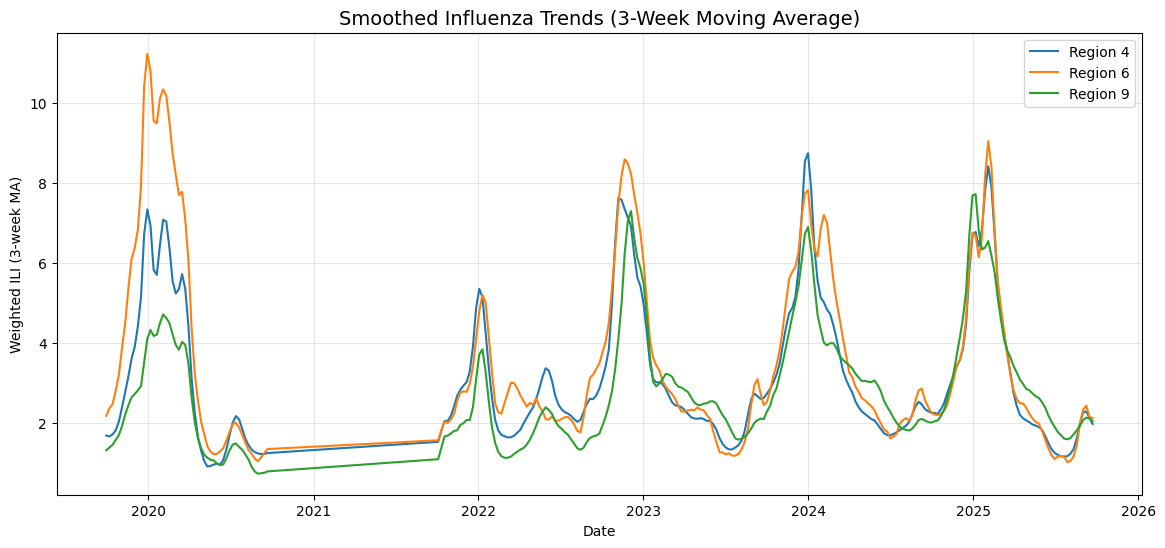

In [ ]:
plt.figure(figsize=(14, 6))

for region in master_data["Region"].unique():
    subset = master_data[master_data["Region"] == region]
    plt.plot(subset["Date"], subset["Weighted_ILI_MA3"], label=region)

plt.title("Smoothed Influenza Trends (3-Week Moving Average)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Weighted ILI (3-week MA)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

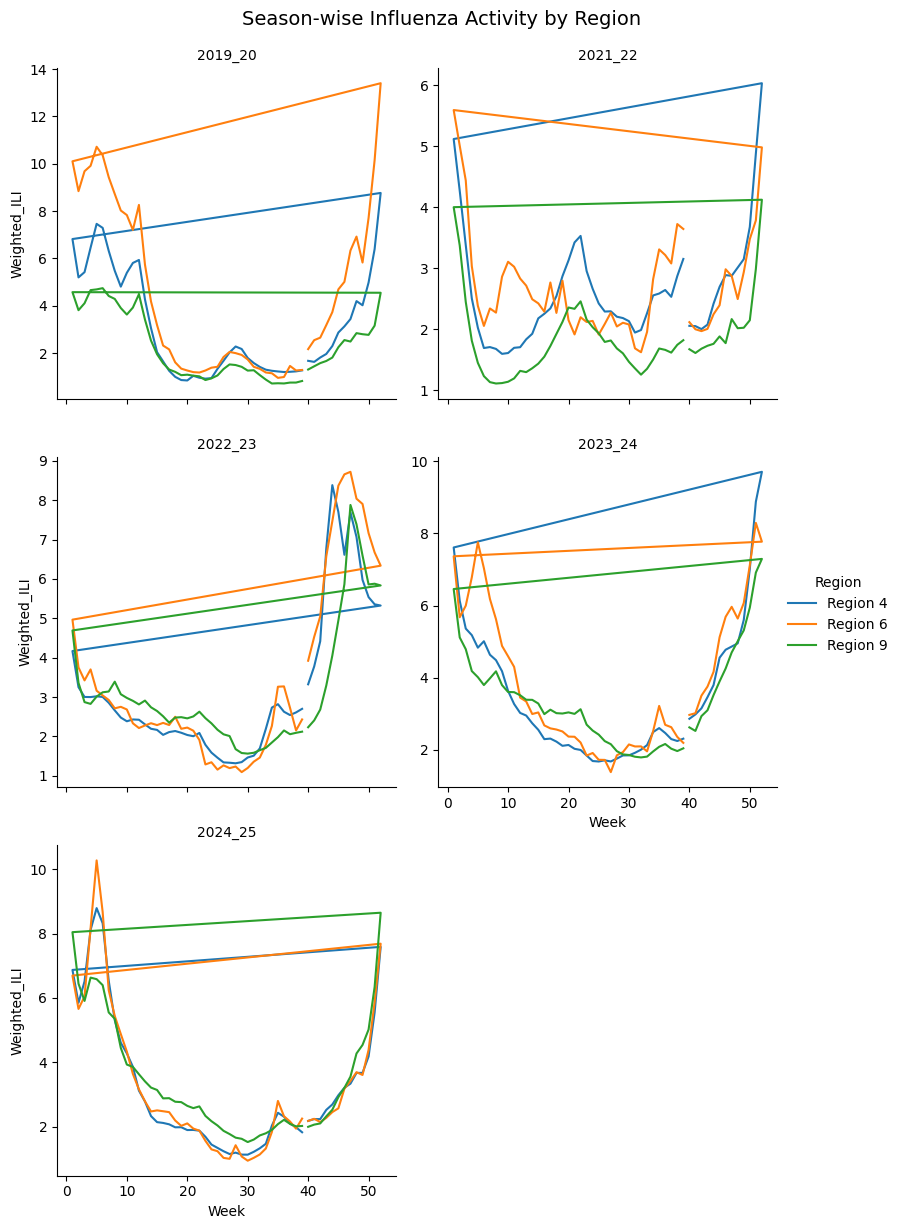

In [ ]:
g = sns.FacetGrid(master_data, col="Season", hue="Region", col_wrap=2, height=4, sharey=False)
g.map(plt.plot, "Week", "Weighted_ILI")
g.add_legend()
g.set_titles("{col_name}")
g.fig.suptitle("Season-wise Influenza Activity by Region", y=1.02, fontsize=14)
plt.show()

In [ ]:
peak_summary = master_data.loc[
    master_data.groupby(["Region", "Season"])["Weighted_ILI"].idxmax(),
    ["Region", "Season", "Week", "Date", "Weighted_ILI"]
].sort_values(["Season", "Region"])

peak_summary

,Region,Season,Week,Date,Weighted_ILI
12,Region 4,2019_20,52,2019-12-23,8.76758
272,Region 6,2019_20,52,2019-12-23,13.40260
538,Region 9,2019_20,6,2020-02-03,4.74509
64,Region 4,2021_22,52,2021-12-27,6.03186
325,Region 6,2021_22,1,2022-01-03,5.59210
584,Region 9,2021_22,52,2021-12-27,4.12248
108,Region 4,2022_23,44,2022-10-31,8.38326
371,Region 6,2022_23,47,2022-11-21,8.72204
631,Region 9,2022_23,47,2022-11-21,7.88031
168,Region 4,2023_24,52,2023-12-25,9.71012


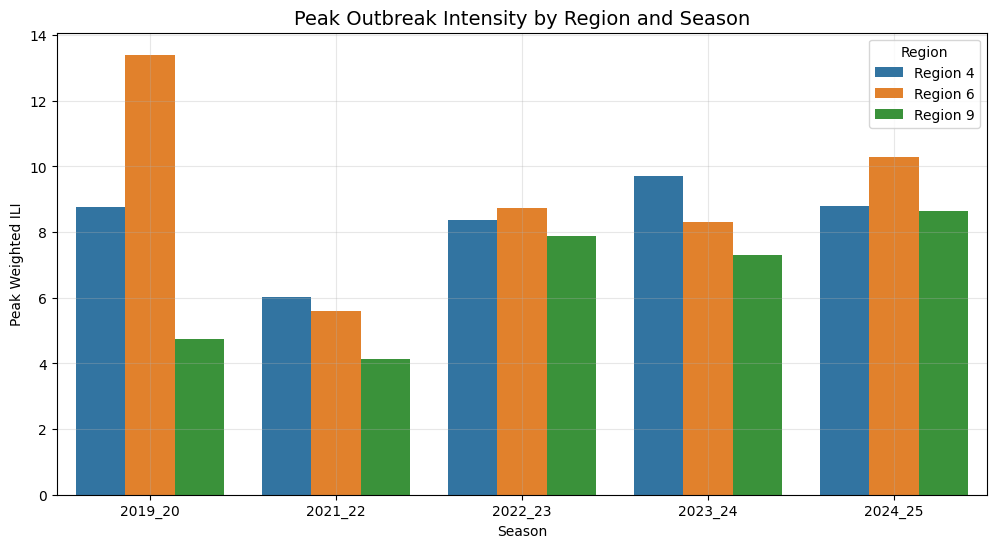

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=peak_summary, x="Season", y="Weighted_ILI", hue="Region")
plt.title("Peak Outbreak Intensity by Region and Season", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Peak Weighted ILI")
plt.legend(title="Region")
plt.grid(True, alpha=0.3)
plt.show()

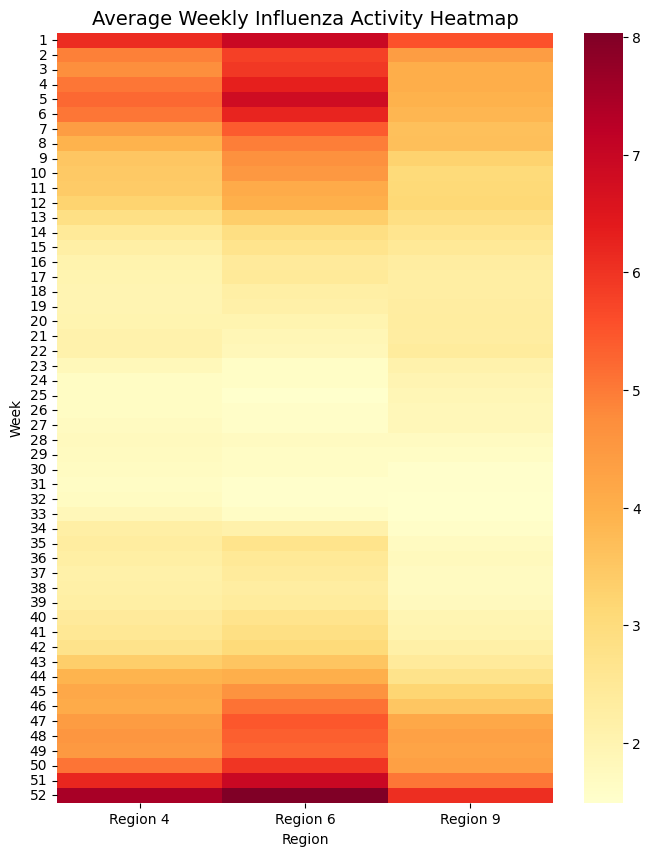

In [ ]:
pivot_heatmap = master_data.pivot_table(
    index="Week",
    columns="Region",
    values="Weighted_ILI",
    aggfunc="mean"
)

plt.figure(figsize=(8, 10))
sns.heatmap(pivot_heatmap, cmap="YlOrRd", annot=False)
plt.title("Average Weekly Influenza Activity Heatmap", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Week")
plt.show()

In [ ]:
region_pivot = master_data.pivot_table(
    index="Date",
    columns="Region",
    values="Weighted_ILI"
)

correlation_matrix = region_pivot.corr()
correlation_matrix

Region,Region 4,Region 6,Region 9
Region,,,
Region 4,1.000000,0.928841,0.878194
Region 6,0.928841,1.000000,0.782348
Region 9,0.878194,0.782348,1.000000


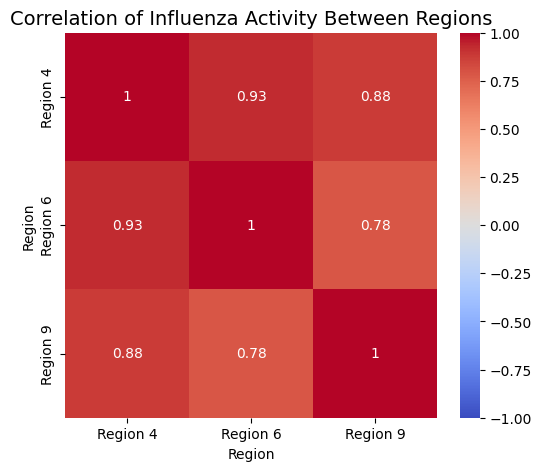

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Influenza Activity Between Regions", fontsize=14)
plt.show()

In [ ]:
eda_summary = master_data.groupby("Region").agg({
    "Weighted_ILI": ["mean", "max", "std"],
    "ILI_per_100k": ["mean", "max", "std"]
}).round(2)

eda_summary

Weighted_ILI              ILI_per_100k              
                 mean    max   std         mean    max    std
Region                                                       
Region 4         3.13   9.71  1.86        24.24  80.70  15.06
Region 6         3.55  13.40  2.38        10.45  33.53   7.52
Region 9         2.80   8.65  1.53        17.08  61.90  14.40

In [ ]:
peak_summary.to_csv("/content/peak_summary_by_region_season.csv", index=False)
eda_summary.to_csv("/content/eda_summary_statistics.csv")

print("Saved peak_summary_by_region_season.csv")
print("Saved eda_summary_statistics.csv")

Saved peak_summary_by_region_season.csv
Saved eda_summary_statistics.csv


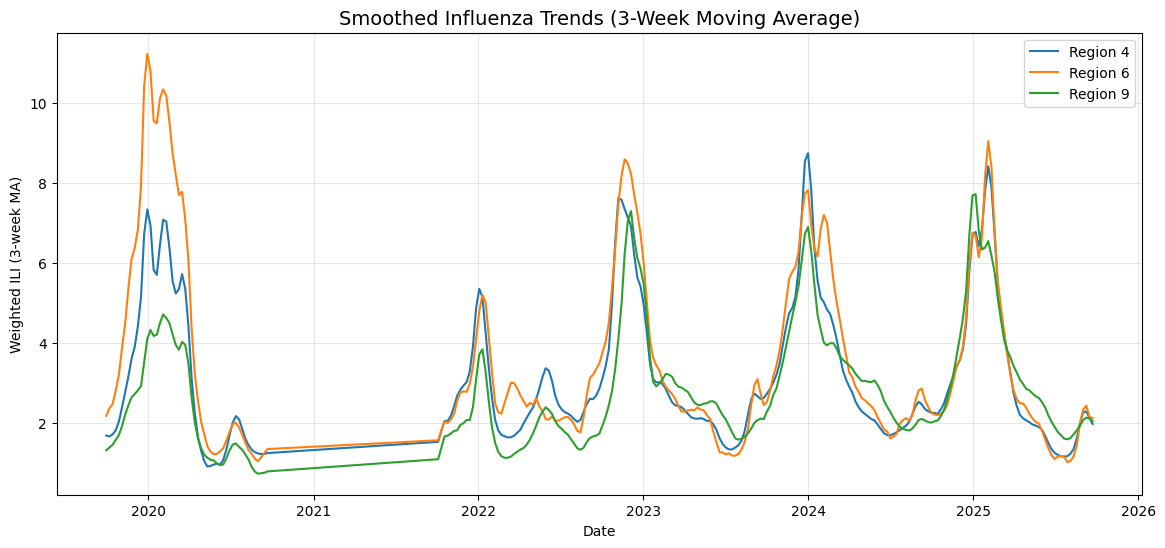

In [ ]:
plt.figure(figsize=(14, 6))

for region in master_data["Region"].unique():
    subset = master_data[master_data["Region"] == region]
    plt.plot(subset["Date"], subset["Weighted_ILI_MA3"], label=region)

plt.title("Smoothed Influenza Trends (3-Week Moving Average)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Weighted ILI (3-week MA)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("/content/smoothed_trends_plot.png", dpi=300, bbox_inches="tight")
plt.show()